In [1]:
from constants import DATA_ROOT_PATH_NAME, BANDPASS, HAMPEL_WINDOW_SIZE, HAMPEL_N_SIGMA, CROP_TMIN, CROP_TMAX, LOCAL_DETREND_WINDOW_SEC, LOCAL_DETREND_STEP_SEC, ASR_CUTOFF, ASR_BLOCKSIZE, ASR_WIN_LEN, ASR_WIN_OVERLAP, ASR_MAX_DROPOUT_FRACTION, ASR_MIN_CLEAN_FRACTION, ASR_MAX_BAD_CHANS

from preprocessing.step.bandpass import BandpassFilterStep
from preprocessing.step.detrend import LocalDetrendStep
from preprocessing.step.hampel import HampelFilterStep
from preprocessing.step.asr import ASRStep
from preprocessing.step.crop import CropStep

from preprocessing.pipeline import PreprocessingPipeline
import numpy as np

from features.factory import FeatureExtractionEngine, FeatureExtractionConfig
from features.categories import FeatureCategory

from eeg.data import EEGRecordedDataProvider

from features.visualization import ExtractedFeatureHeatmapFactory



%load_ext autoreload
%autoreload 2

# Création des 2 datasets de features

In [2]:
recordings = EEGRecordedDataProvider.build(DATA_ROOT_PATH_NAME)

/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Did not find any events.tsv associated with sub-001_task-eyesclosed.

The search_str was "data/sub-001/**/eeg/sub-001*events.tsv"
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 57
Group: A
MMSE: 16
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Did not find any events.tsv associated with sub-002_task-eyesclosed.

The search_str was "data/sub-002/**/eeg/sub-002*events.tsv"
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 78
Group: A
MMSE: 22
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:121: RuntimeWarning: Did not fin

In [3]:
asr_pipeline = PreprocessingPipeline(name="ASR",
                                        steps=[
                                                BandpassFilterStep(BANDPASS),
                                                CropStep(tmin=CROP_TMIN, tmax=CROP_TMAX),
                                                ASRStep(cutoff=ASR_CUTOFF, blocksize=ASR_BLOCKSIZE, win_len=ASR_WIN_LEN, win_overlap=ASR_WIN_OVERLAP, max_dropout_fraction=ASR_MAX_DROPOUT_FRACTION, min_clean_fraction=ASR_MIN_CLEAN_FRACTION, max_bad_chans=ASR_MAX_BAD_CHANS)
                                                ])

dethamp_pipeline = PreprocessingPipeline(name="det-hamp",
                                        steps=[ 
                                                BandpassFilterStep(BANDPASS),
                                                CropStep(tmin=CROP_TMIN, tmax=CROP_TMAX),
                                                LocalDetrendStep(window_sec=LOCAL_DETREND_WINDOW_SEC, step_sec=LOCAL_DETREND_STEP_SEC),
                                                HampelFilterStep(window_size=HAMPEL_WINDOW_SIZE, n_sigma=HAMPEL_N_SIGMA)
                                                ])

In [4]:
recorded_eeg = recordings[14]
asr_processed_eeg = asr_pipeline.compute(recorded_eeg)
dethamp_processed_eeg = dethamp_pipeline.compute(recorded_eeg)

In [5]:
categories_to_extract = [FeatureCategory.WAVELET, FeatureCategory.TEMPORAL, FeatureCategory.POWER_RATIO, FeatureCategory.SPECTRAL]
config = FeatureExtractionConfig(categories_to_extract=categories_to_extract, wamp_threshold=10e-9, ppc_epoch_duration=2)
feature_extraction_engine = FeatureExtractionEngine(config=config)

dethamp_processed_extraction_result = feature_extraction_engine.extract(dethamp_processed_eeg)
dethamp_processed_extracted_feature_heatmap_factory = ExtractedFeatureHeatmapFactory(dethamp_processed_extraction_result)

asr_processed_extraction_result = feature_extraction_engine.extract(asr_processed_eeg)
asr_processed_extracted_feature_heatmap_factory = ExtractedFeatureHeatmapFactory(asr_processed_extraction_result)

/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:395: RuntimeWarning: fmin=1.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 2.000 sec, need at least 5.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(
/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:395: RuntimeWarning: fmin=1.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 2.000 sec, need at least 5.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(


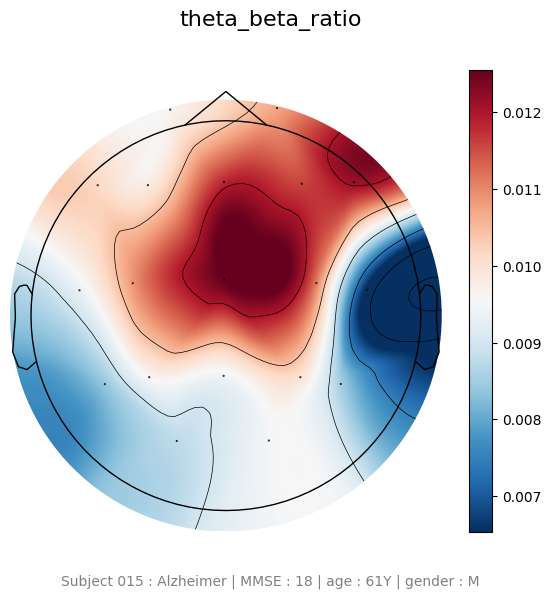

In [6]:
dethamp_processed_extracted_feature_heatmap_factory.plot("theta_beta_ratio")

In [9]:
from features.dataset import FeatureDataset, FeatureDatasetFactory
from features.io import FeatureDatasetIO

feature_dataset = FeatureDatasetFactory.from_extraction_result(dethamp_processed_extraction_result)

TypeError: FeatureDataset.__init__() missing 1 required positional argument: 'eeg_info'

In [ ]:
FeatureDatasetIO.export(feature_dataset, "computed_data")

In [15]:
help(dethamp_processed_extraction_result.eeg.info)

Help on Info in module mne._fiff.meas_info object:

class Info(ValidatedDict, SetChannelsMixin, MontageMixin, ContainsMixin)
 |  Info(*args, **kwargs)
 |
 |  Measurement information.
 |
 |  This data structure behaves like a dictionary. It contains all metadata
 |  that is available for a recording. However, its keys are restricted to
 |  those provided by the
 |  `FIF format specification <https://github.com/mne-tools/fiff-constants>`__,
 |  so new entries should not be manually added.
 |
 |  .. note::
 |      This class should not be instantiated directly via
 |      ``mne.Info(...)``. Instead, use :func:`mne.create_info` to create
 |      measurement information from scratch.
 |
 |  .. warning::
 |      The only entries that should be manually changed by the user are:
 |      ``info['bads']``, ``info['description']``, ``info['device_info']``,
 |      ``info['proj_id']``, ``info['proj_name']``, ``info['dev_head_t']``,
 |      ``info['experimenter']``, ``info['helium_info']``,
 |     

In [17]:
dethamp_processed_extraction_result.eeg.info.to_json_dict()

{'acq_pars': None,
 'acq_stim': None,
 'ctf_head_t': None,
 'description': None,
 'dev_head_t': None,
 'dev_ctf_t': None,
 'dig': [{'kind': {'_mne_type': 'NamedInt',
    'value': 1,
    'name': 'FIFFV_POINT_CARDINAL'},
   'r': [-0.08248999847728919, -3.913088162527112e-09, 9.395539901646544e-13],
   'ident': {'_mne_type': 'NamedInt', 'value': 1, 'name': 'FIFFV_POINT_LPA'},
   'coord_frame': {'_mne_type': 'NamedInt',
    'value': 4,
    'name': 'FIFFV_COORD_HEAD'}},
  {'kind': {'_mne_type': 'NamedInt',
    'value': 1,
    'name': 'FIFFV_POINT_CARDINAL'},
   'r': [5.383374011326547e-09, 0.11404662483597017, 2.1455351384425114e-11],
   'ident': {'_mne_type': 'NamedInt',
    'value': 2,
    'name': 'FIFFV_POINT_NASION'},
   'coord_frame': {'_mne_type': 'NamedInt',
    'value': 4,
    'name': 'FIFFV_COORD_HEAD'}},
  {'kind': {'_mne_type': 'NamedInt',
    'value': 1,
    'name': 'FIFFV_POINT_CARDINAL'},
   'r': [0.08249001337835624, 3.8600762586327164e-09, -9.484218965738478e-13],
   'ident'

In [ ]:
raw : mne.io.Raw = None

In [ ]:
info : mne.meas_inof = None



# Tests statistiques

In [18]:
pip freeze

asrpy==0.0.8
asttokens==3.0.1
certifi==2026.2.25
cftime==1.6.5
charset-normalizer==3.4.6
comm==0.2.3
contourpy==1.3.3
cramjam==2.11.0
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
executing==2.2.1
fastparquet==2026.3.0
fonttools==4.62.1
fsspec==2026.3.0
idna==3.11
ipykernel==7.2.0
ipython==9.12.0
ipython_pygments_lexers==1.1.1
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
jupyter_client==8.8.0
jupyter_core==5.9.1
kiwisolver==1.5.0
lazy-loader==0.5
MarkupSafe==3.0.3
matplotlib==3.10.8
matplotlib-inline==0.2.1
mne==1.11.0
mne-bids==0.18.0
mne-connectivity==0.8
nest-asyncio==1.6.0
netCDF4==1.7.4
numpy==2.3.0
packaging==26.0
pandas==3.0.2
parso==0.8.6
pexpect==4.9.0
pillow==12.1.1
platformdirs==4.9.4
pooch==1.9.0
prompt_toolkit==3.0.52
psutil==7.2.2
ptyprocess==0.7.0
pure_eval==0.2.3
pyarrow==23.0.1
Pygments==2.20.0
pyparsing==3.3.2
python-dateutil==2.9.0.post0
PyWavelets==1.9.0
pyzmq==27.1.0
requests==2.33.1
scikit-learn==1.8.0
scipy==1.17.1
six==1.17.0
stack-data==0.6.3
threadpoolctl==3.6.0